# **Practical Q2: California Housing Ridge Regression**

### Import Libraries

In [7]:
# Improting needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



---


## Part (a) Load California Housing dataset and split into train/test (80/20)

In [8]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

print("Shape X:", X.shape, "| y:", y.shape, "| Target: MedHouseVal")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

Shape X: (20640, 8) | y: (20640,) | Target: MedHouseVal




---

## Part (b) Utility function to train Poly(degree) -> Scaler -> Ridge


#### * Defining train_poly_ridge function
This function generates polynomial features, scales the data, applies Ridge regression, and selects the best alpha value using 5-fold CV.


In [9]:
def train_poly_ridge(degree):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])

    param_grid = {"ridge__alpha": np.logspace(-3, 3, 13)}

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    gs = GridSearchCV(
        pipe,
        param_grid,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)

    result = {
        "degree": degree,
        "best_alpha": gs.best_params_["ridge__alpha"],
        "mse_test": mean_squared_error(y_test, y_pred),
        "r2_test": r2_score(y_test, y_pred)
    }

    return result

### Running the Model for Polynomial Degrees 1, 2, and 3
Here we call the function for each degree and print the best alpha,
test MSE, and test R² for comparison.

In [10]:
# Train models for degrees 1, 2, 3
results = [train_poly_ridge(d) for d in [1, 2, 3]]

# Print results
for r in results:
    print("Degree:", r["degree"],
          "| Best alpha:", r["best_alpha"],
          "| Test MSE:", r["mse_test"],
          "| Test R^2:", r["r2_test"])

Degree: 1 | Best alpha: 3.1622776601683795 | Test MSE: 0.5557762384947302 | Test R^2: 0.5758757397703369
Degree: 2 | Best alpha: 1000.0 | Test MSE: 0.5591540579724756 | Test R^2: 0.5732980563647487
Degree: 3 | Best alpha: 1000.0 | Test MSE: 0.5760937849103626 | Test R^2: 0.5603710028881869




---

## Part (c) Final evaluation and Plotting

### Collecting MSE and R² Values for Plotting


In [11]:
# Parameters used for for plotting
degrees = [r["degree"] for r in results]
mses = [r["mse_test"] for r in results]
r2s = [r["r2_test"] for r in results]

### Plotting: Polynomial Degree vs Test MSE

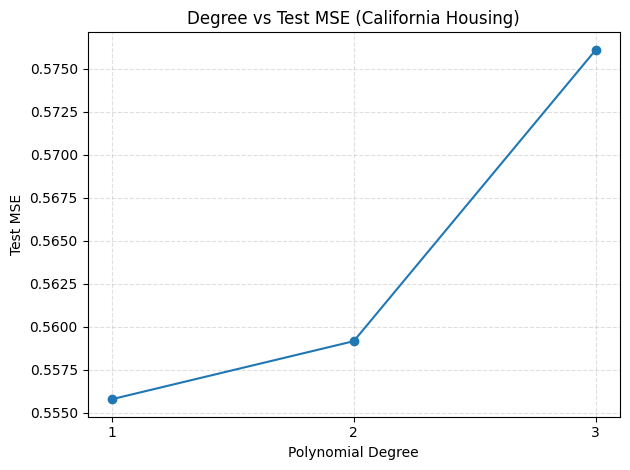

In [12]:
# Plot Degree vs Test MSE
plt.figure()
plt.plot(degrees, mses, marker="o")
plt.xticks(degrees)
plt.xlabel("Polynomial Degree")
plt.ylabel("Test MSE")
plt.title("Degree vs Test MSE (California Housing)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Plotting: Polynomial Degree vs Test R²

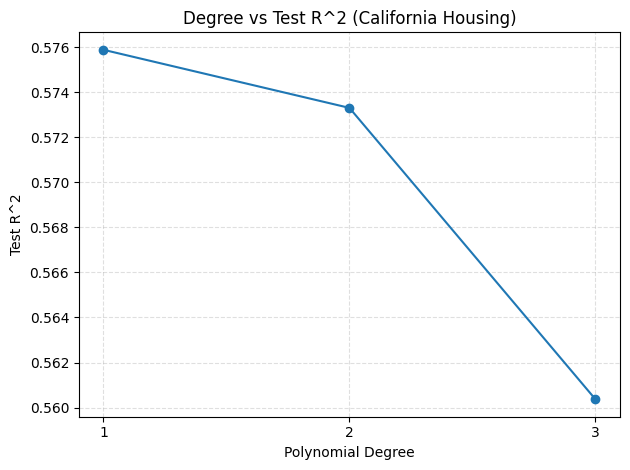

In [13]:
# Plot Degree vs Test R^2
plt.figure()
plt.plot(degrees, r2s, marker="o")
plt.xticks(degrees)
plt.xlabel("Polynomial Degree")
plt.ylabel("Test R^2")
plt.title("Degree vs Test R^2 (California Housing)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()